# Random Forest Regressor — Health Score Prediction

## Import Libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

## Load Data

In [18]:
df = pd.read_csv('../Medallion Architecture/data/silver_layer/usda_clean_data.csv')
df.head()

,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,calories,carbs_g,calcium_mg,fat_g,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
0,167782,abiyuch raw,SR Legacy,Fruits and Fruit Juices,No Brand,No Brand,69.0,17.60,8.0,0.10,1.50,0.014,54.1,5.3,1.61,20.0,8.55,0.0,65,Fruits
1,171687,acerola juice raw,SR Legacy,Fruits and Fruit Juices,No Brand,No Brand,23.0,4.80,10.0,0.30,0.40,0.068,1600.0,0.3,0.50,3.0,4.50,0.0,55,Fruits
2,171686,acerola west indian cherry raw,SR Legacy,Fruits and Fruit Juices,No Brand,No Brand,32.0,7.69,12.0,0.30,0.40,0.068,1680.0,1.1,0.20,7.0,10.40,0.0,55,Fruits
3,168061,acorn stew apache,SR Legacy,American Indian/Alaska Native Foods,No Brand,No Brand,95.0,9.22,14.0,3.47,6.81,1.280,0.0,0.7,1.00,130.0,0.34,20.0,50,Other
4,168992,agave cooked southwest,SR Legacy,American Indian/Alaska Native Foods,No Brand,No Brand,134.6,32.00,460.0,0.29,0.99,1.330,0.3,10.6,3.55,13.0,20.90,0.0,50,Other


## Define Features and Target

**Features (X):** `calories`, `protein_g`, `fat_g`, `carbs_g`, `fiber_g`, `sugar_g`, `sodium_mg`, `saturated_fat_g`, `cholesterol_mg`  
**Target (Y):** `health_score`

In [19]:
X = df[['calories', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'saturated_fat_g', 'cholesterol_mg']]
Y = df['health_score']

## Train / Test Split

80% training — 20% test, `random_state=42` for reproducibility.

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=42)
print(f"\n Training Set Size: {X_train.shape[0]}")
print(f"Test Set Size: {X_test.shape[0]}")



 Training Set Size: 31997
Test Set Size: 8000


## Define Model

In [21]:
regressor = RandomForestRegressor(
    n_estimators=100,       # number of trees in the forest
    max_depth=15,          # maximum depth of each tree
    min_samples_leaf=4,    # minimum samples required at a leaf node
    min_samples_split=8,   # minimum samples required to split an internal node
    random_state=42,       # seed for reproducibility
    n_jobs=-1              # use all available CPU cores
)

## Train Model

In [22]:
# training the model
regressor.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Cross-Validation (5-Fold)

Cross-validation confirms model generalizes well across different data splits — not just one lucky split.

In [23]:
cv_scores = cross_val_score(regressor, X, Y, cv=5, scoring='r2', n_jobs=-1)
print("\n" + "="*50)
print("Cross-Validation Results (5-Fold)")
print("="*50)
print(f"R² Scores per fold: {np.round(cv_scores, 4)}")
print(f"Mean R²:            {cv_scores.mean():.4f}")
print(f"Std R²:             {cv_scores.std():.4f}")
print("\n Low std = model is stable across different data splits")


Cross-Validation Results (5-Fold)
R² Scores per fold: [0.9493 0.9728 0.9812 0.9614 0.9718]
Mean R²:            0.9673
Std R²:             0.0110

 Low std = model is stable across different data splits


## Generate Predictions

In [24]:
# prediction on Test Data
test_data_prediction = regressor.predict(X_test)
train_data_prediction = regressor.predict(X_train)
print(test_data_prediction)

[59.99453079 50.0144278  31.21498771 ... 59.80916667 40.09166667
 50.11456148]


## Evaluate Model

In [25]:
# R squared error
r2_test = metrics.r2_score(Y_test, test_data_prediction)
r2_train = metrics.r2_score(Y_train, train_data_prediction)

# Mean Absolute Error (MAE)
mae_test = mean_absolute_error(Y_test, test_data_prediction)
mae_train = mean_absolute_error(Y_train, train_data_prediction)

# Root Mean Square Error (RMSE)
rmse_test = np.sqrt(mean_squared_error(Y_test, test_data_prediction))
rmse_train = np.sqrt(mean_squared_error(Y_train, train_data_prediction))

# Calculate additional errors
errors = Y_test.values - test_data_prediction

print(f"\n Test Data Metrics:")
print(f"   R² Score:           {r2_test:.6f}")
print(f"   MAE (Mean Absolute Error):     {mae_test:.4f}")
print(f"   RMSE (Root Mean Square Error):  {rmse_test:.4f}")

print(f"\n Train Data Metrics:")
print(f"   R² Score:           {r2_train:.6f}")
print(f"   MAE:                {mae_train:.4f}")
print(f"   RMSE:               {rmse_train:.4f}")

# Overfitting check
r2_gap = r2_train - r2_test
print("\n" + "="*50)
print(f"Overfitting Check → Train-Test R² Gap: {r2_gap:.4f}")
if r2_gap < 0.02:
    print("No overfitting detected — gap < 0.02")
elif r2_gap < 0.05:
    print("Slight overfitting — gap between 0.02 and 0.05")
else:
    print("Overfitting detected — gap > 0.05, consider tuning")


 Test Data Metrics:
   R² Score:           0.979304
   MAE (Mean Absolute Error):     0.6758
   RMSE (Root Mean Square Error):  1.4239

 Train Data Metrics:
   R² Score:           0.986336
   MAE:                0.5520
   RMSE:               1.1501

Overfitting Check → Train-Test R² Gap: 0.0070
No overfitting detected — gap < 0.02


## Feature Importance

In [26]:
# Feature Importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': regressor.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(feature_importance_df)

           Feature  Importance
0          sugar_g    0.267495
1  saturated_fat_g    0.211167
2        protein_g    0.186101
3          fiber_g    0.173603
4        sodium_mg    0.151065
5          carbs_g    0.005875
6         calories    0.002867
7            fat_g    0.001346
8   cholesterol_mg    0.000482


## Visualizations

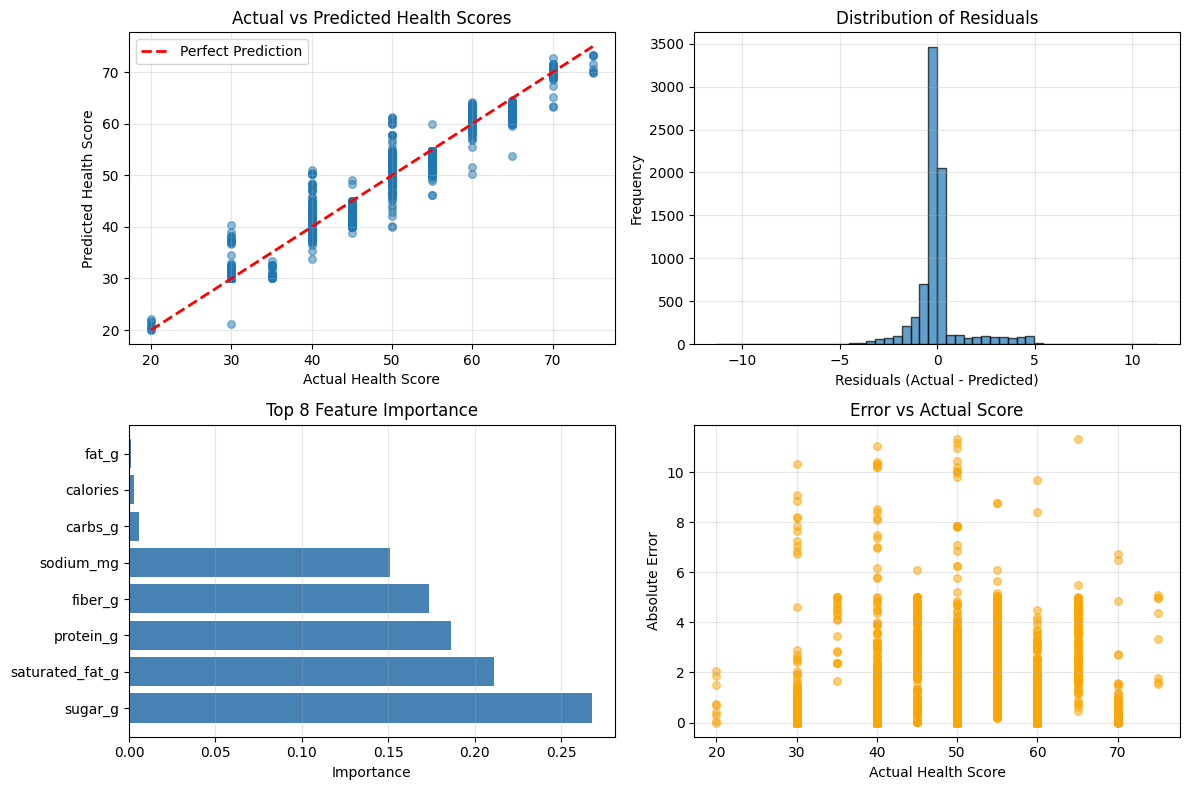

In [27]:
# 1. Actual vs Predicted
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.scatter(Y_test, test_data_prediction, alpha=0.5, s=30)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Health Score')
plt.ylabel('Predicted Health Score')
plt.title('Actual vs Predicted Health Scores')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Residuals Distribution
plt.subplot(2, 2, 2)
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)

# 3. Feature Importance
plt.subplot(2, 2, 3)
top_features = feature_importance_df.head(8)
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 8 Feature Importance')
plt.grid(True, alpha=0.3, axis='x')

# 4. Error Distribution
plt.subplot(2, 2, 4)
plt.scatter(Y_test, np.abs(errors), alpha=0.5, s=30, color='orange')
plt.xlabel('Actual Health Score')
plt.ylabel('Absolute Error')
plt.title('Error vs Actual Score')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Export Results for Power BI

In [28]:
# Export DataFrames for Power BI
# ============================================
print("\n" + "="*50)
print("Exporting results...")
print("="*50)

# 1. Full predictions table
predictions_df = pd.DataFrame({
    'Actual_Health_Score': Y_test.values,
    'Predicted_Health_Score': test_data_prediction,
    'Difference': Y_test.values - test_data_prediction,
    'Absolute_Error': np.abs(Y_test.values - test_data_prediction),
    'Error_Percentage': np.abs((Y_test.values - test_data_prediction) / Y_test.values * 100),
    'Is_Accurate_10Percent': np.abs(Y_test.values - test_data_prediction) <= (Y_test.values * 0.1)
})

# Concatenate with input features
predictions_full = pd.concat([
    X_test.reset_index(drop=True),
    predictions_df.reset_index(drop=True)
], axis=1)

predictions_full.to_csv('predictions_for_powerbi.csv', index=False)
print("Saved: predictions_for_powerbi.csv")

# 2. Model metrics summary table
metrics_summary = pd.DataFrame({
    'R2_Test': [round(r2_test, 6)],
    'R2_Train': [round(r2_train, 6)],

    'MAE_Test': [round(mae_test, 4)],
    'MAE_Train': [round(mae_train, 4)],

    'RMSE_Test': [round(rmse_test, 4)],
    'RMSE_Train': [round(rmse_train, 4)],
    
    'CV_Mean_R2': [round(cv_scores.mean(), 4)],
    'CV_Std_R2':  [round(cv_scores.std(), 4)],

    'Total_Predictions': [len(Y_test)],
})

metrics_summary.to_csv('model_metrics.csv', index=False)
print("Saved: model_metrics.csv")

# 3. Feature importance table
feature_importance_df.to_csv('feature_importance.csv', index=False)
print("Saved: feature_importance.csv")

# 4. Detailed prediction errors table
errors_detailed = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': test_data_prediction,
    'Residual': errors,
    'Absolute_Residual': np.abs(errors),
    'Squared_Residual': errors ** 2
})

errors_detailed.to_csv('prediction_errors.csv', index=False)
print("Saved: prediction_errors.csv")



Exporting results...
Saved: predictions_for_powerbi.csv
Saved: model_metrics.csv
Saved: feature_importance.csv
Saved: prediction_errors.csv
